In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 773.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 2.9 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import os
import yaml

print("Ultralytics imported successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics imported successfully!


In [ ]:
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 4.4 MB/s eta 0:00:00


In [ ]:
from roboflow import Roboflow

API_KEY = "O5PXZAlAqKO2hF2VRk80"

rf = Roboflow(api_key=API_KEY)

In [ ]:
pothole_project = rf.workspace("umat").project("pothole-abpqz")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
traffic_project = rf.workspace("traffic-final").project("traffic-signs-aaspe")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
print("Pothole versions:")

for v in pothole_project.versions():
    print(v.version)

print("\nTraffic Signs versions:")

for v in traffic_project.versions():
    print(v.version)

Pothole versions:
1

Traffic Signs versions:
3
2
1


In [ ]:
pothole_version = pothole_project.version(1)
traffic_version = traffic_project.version(3)

print("Pothole Version:", pothole_version.version)
print("Traffic Version:", traffic_version.version)

Pothole Version: 1
Traffic Version: 3


In [ ]:
pothole_dataset = pothole_version.download("yolov8")
traffic_dataset = traffic_version.download("yolov8")

print("Pothole:", pothole_dataset.location)
print("Traffic:", traffic_dataset.location)


Extracting Dataset Version Zip to Pothole-1 in yolov8:: 100%|██████████| 1122/1122 [00:00<00:00, 1897.09it/s]


Extracting Dataset Version Zip to traffic-signs-3 in yolov8:: 100%|██████████| 9246/9246 [00:01<00:00, 6267.93it/s]


Pothole: /content/Pothole-1
Traffic: /content/traffic-signs-3


In [ ]:
pothole_dataset = pothole_version.download("yolov8")
traffic_dataset = traffic_version.download("yolov8")

pothole_path = pothole_dataset.location
traffic_path = traffic_dataset.location

print("Pothole path:", pothole_path)
print("Traffic path:", traffic_path)

Pothole path: /content/Pothole-1
Traffic path: /content/traffic-signs-3


In [ ]:
import os
import yaml

print("Pothole path:", pothole_dataset.location)
print("Traffic path:", traffic_dataset.location)

# قراءة data.yaml
with open(os.path.join(pothole_dataset.location, "data.yaml"), "r") as f:
    pothole_yaml = yaml.safe_load(f)

with open(os.path.join(traffic_dataset.location, "data.yaml"), "r") as f:
    traffic_yaml = yaml.safe_load(f)

print("\nPothole classes:")
print(pothole_yaml["names"])

print("\nTraffic classes:")
print(traffic_yaml["names"])

Pothole path: /content/Pothole-1
Traffic path: /content/traffic-signs-3

Pothole classes:
['pothole']

Traffic classes:
['Bump', 'No_Parking', 'No_Stopping', 'No_U-Turn', 'Pedestrian', 'Road_Work', 'Speed_Limit_120', 'Speed_Limit_40', 'Speed_Limit_90', 'Stop']


In [ ]:
from collections import Counter
import glob

def count_classes(dataset_path, yaml_data):
    names = yaml_data["names"]

    if isinstance(names, dict):
        names = [names[i] for i in sorted(names.keys(), key=int)]

    counter = Counter()

    label_files = glob.glob(
        os.path.join(dataset_path, "train", "labels", "*.txt")
    )

    for file in label_files:
        with open(file, "r") as f:
            for line in f:
                line = line.strip()

                if not line:
                    continue

                class_id = int(line.split()[0])
                counter[names[class_id]] += 1

    return counter


pothole_counts = count_classes(
    pothole_path,
    pothole_yaml
)

traffic_counts = count_classes(
    traffic_dataset.location,
    traffic_yaml
)

print("POTHOLE")
for cls, count in pothole_counts.items():
    print(cls, ":", count)

print("\nTRAFFIC SIGNS")
for cls, count in traffic_counts.items():
    print(cls, ":", count)

POTHOLE
pothole : 2025

TRAFFIC SIGNS
No_U-Turn : 394
Speed_Limit_120 : 499
Stop : 622
Speed_Limit_90 : 269
No_Stopping : 256
Pedestrian : 526
Speed_Limit_40 : 421
Road_Work : 147
No_Parking : 245
Bump : 162


In [ ]:
all_counts = {}

all_counts.update(pothole_counts)
all_counts.update(traffic_counts)

print("\n========== ALL CLASSES ==========")

for cls, count in all_counts.items():
    print(f"{cls:20s} : {count}")


========== ALL CLASSES ==========
pothole              : 2025
No_U-Turn            : 394
Speed_Limit_120      : 499
Stop                 : 622
Speed_Limit_90       : 269
No_Stopping          : 256
Pedestrian           : 526
Speed_Limit_40       : 421
Road_Work            : 147
No_Parking           : 245
Bump                 : 162


In [ ]:
from collections import Counter
import os
import glob

def count_images_per_class(dataset_path, yaml_data):
    names = yaml_data["names"]

    if isinstance(names, dict):
        names = [names[i] for i in sorted(names.keys(), key=int)]

    counter = Counter()

    label_files = glob.glob(
        os.path.join(dataset_path, "train", "labels", "*.txt")
    )

    for file in label_files:
        classes_in_image = set()

        with open(file, "r") as f:
            for line in f:
                line = line.strip()

                if not line:
                    continue

                class_id = int(line.split()[0])
                classes_in_image.add(names[class_id])

        for cls in classes_in_image:
            counter[cls] += 1

    return counter


pothole_image_counts = count_images_per_class(
    pothole_path,
    pothole_yaml
)

traffic_image_counts = count_images_per_class(
    traffic_dataset.location,
    traffic_yaml
)

all_image_counts = {}

all_image_counts.update(pothole_image_counts)
all_image_counts.update(traffic_image_counts)

print("========== IMAGES PER CLASS ==========")

for cls, count in all_image_counts.items():
    print(f"{cls:20s} : {count}")

========== IMAGES PER CLASS ==========
pothole              : 389
No_U-Turn            : 392
Speed_Limit_120      : 459
Stop                 : 603
Speed_Limit_90       : 260
No_Stopping          : 255
Pedestrian           : 459
Speed_Limit_40       : 418
Road_Work            : 143
No_Parking           : 242
Bump                 : 160


In [ ]:
print("Pothole images:", pothole_image_counts["pothole"])

Pothole images: 389


In [ ]:
TARGET = 400

traffic_counts = {
    "Stop": 603,
    "Pedestrian": 459,
    "Speed_Limit_120": 459,
    "Speed_Limit_40": 418,
    "No_U-Turn": 392,
    "Speed_Limit_90": 260,
    "No_Stopping": 255,
    "No_Parking": 242,
    "Bump": 160,
    "Road_Work": 143
}

pothole_counts = {
    "pothole": 389
}

all_counts = {**pothole_counts, **traffic_counts}

print("========== TARGET ==========")

for cls, count in all_counts.items():
    if count < TARGET:
        print(f"{cls:20s}: {count} → {TARGET}  (+{TARGET-count})")
    else:
        print(f"{cls:20s}: {count} → {TARGET}")

========== TARGET ==========
pothole             : 389 → 400  (+11)
Stop                : 603 → 400
Pedestrian          : 459 → 400
Speed_Limit_120     : 459 → 400
Speed_Limit_40      : 418 → 400
No_U-Turn           : 392 → 400  (+8)
Speed_Limit_90      : 260 → 400  (+140)
No_Stopping         : 255 → 400  (+145)
No_Parking          : 242 → 400  (+158)
Bump                : 160 → 400  (+240)
Road_Work           : 143 → 400  (+257)


In [ ]:
classes = [
    "pothole",
    "Stop",
    "Pedestrian",
    "Speed_Limit_120",
    "Speed_Limit_40",
    "No_U-Turn",
    "Speed_Limit_90",
    "No_Stopping",
    "No_Parking",
    "Bump",
    "Road_Work"
]

print("Number of classes:", len(classes))

for i, cls in enumerate(classes):
    print(i, "→", cls)

Number of classes: 11
0 → pothole
1 → Stop
2 → Pedestrian
3 → Speed_Limit_120
4 → Speed_Limit_40
5 → No_U-Turn
6 → Speed_Limit_90
7 → No_Stopping
8 → No_Parking
9 → Bump
10 → Road_Work


In [ ]:
!pip install -q albumentations

In [ ]:
# Read the REAL class names from each dataset

def normalize_names(names):
    if isinstance(names, dict):
        return [names[i] for i in sorted(names.keys(), key=int)]
    return names


pothole_names = normalize_names(pothole_yaml["names"])
traffic_names = normalize_names(traffic_yaml["names"])

print("Pothole dataset classes:")
for i, name in enumerate(pothole_names):
    print(i, "->", name)

print("\nTraffic dataset classes:")
for i, name in enumerate(traffic_names):
    print(i, "->", name)

Pothole dataset classes:
0 -> pothole

Traffic dataset classes:
0 -> Bump
1 -> No_Parking
2 -> No_Stopping
3 -> No_U-Turn
4 -> Pedestrian
5 -> Road_Work
6 -> Speed_Limit_120
7 -> Speed_Limit_40
8 -> Speed_Limit_90
9 -> Stop


In [ ]:

unique_classes = set(pothole_names)
class_to_id = {name: idx for idx, name in enumerate(unique_classes)}

pothole_mapping = {}
for source_id, name in enumerate(pothole_names):
    if name in class_to_id:
        pothole_mapping[source_id] = class_to_id[name]

In [ ]:
# Create mapping from SOURCE class IDs
# to our FINAL 11-class IDs

pothole_mapping = {}

for source_id, name in enumerate(pothole_names):
    if name in class_to_id:
        pothole_mapping[source_id] = class_to_id[name]


traffic_mapping = {}

for source_id, name in enumerate(traffic_names):
    if name in class_to_id:
        traffic_mapping[source_id] = class_to_id[name]


print("\nPothole mapping:")
print(pothole_mapping)

print("\nTraffic mapping:")
print(traffic_mapping)


Pothole mapping:
{0: 0}

Traffic mapping:
{}


In [ ]:
class_to_id = {cls: i for i, cls in enumerate(classes)}

pothole_mapping = {}
for source_id, name in enumerate(pothole_names):
    if name in class_to_id:
        pothole_mapping[source_id] = class_to_id[name]

traffic_mapping = {}
for source_id, name in enumerate(traffic_names):
    if name in class_to_id:
        traffic_mapping[source_id] = class_to_id[name]

print("\nPothole mapping:", pothole_mapping)
print("Traffic mapping:", traffic_mapping)


Pothole mapping: {0: 0}
Traffic mapping: {0: 9, 1: 8, 2: 7, 3: 5, 4: 2, 5: 10, 6: 3, 7: 4, 8: 6, 9: 1}


In [ ]:
import os
import glob
from collections import defaultdict

# =========================
# FINAL CLASSES
# =========================

classes = [
    "pothole",
    "Stop",
    "Pedestrian",
    "Speed_Limit_120",
    "Speed_Limit_40",
    "No_U-Turn",
    "Speed_Limit_90",
    "No_Stopping",
    "No_Parking",
    "Bump",
    "Road_Work"
]

class_to_id = {
    name: i for i, name in enumerate(classes)
}


# =========================
# NORMALIZE YAML NAMES
# =========================

def normalize_names(names):

    if isinstance(names, dict):
        return [
            names[i]
            for i in sorted(names.keys(), key=int)
        ]

    return names


pothole_names = normalize_names(
    pothole_yaml["names"]
)

traffic_names = normalize_names(
    traffic_yaml["names"]
)


# =========================
# CREATE MAPPINGS
# =========================

pothole_mapping = {
    source_id: class_to_id[name]
    for source_id, name in enumerate(pothole_names)
    if name in class_to_id
}

traffic_mapping = {
    source_id: class_to_id[name]
    for source_id, name in enumerate(traffic_names)
    if name in class_to_id
}


print("Pothole mapping:", pothole_mapping)
print("Traffic mapping:", traffic_mapping)


# =========================
# IMAGE EXTENSIONS
# =========================

image_extensions = [
    "*.jpg",
    "*.jpeg",
    "*.png",
    "*.JPG",
    "*.JPEG",
    "*.PNG"
]


def get_images(folder):

    files = []

    for ext in image_extensions:
        files.extend(
            glob.glob(
                os.path.join(folder, ext)
            )
        )

    return sorted(files)


# =========================
# READ YOLO LABELS
# =========================

def read_yolo_labels(label_path):

    boxes = []
    labels = []

    if not os.path.exists(label_path):
        return boxes, labels

    with open(label_path, "r") as f:

        for line in f:

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            source_id = int(parts[0])

            x, y, w, h = map(
                float,
                parts[1:]
            )

            boxes.append(
                [x, y, w, h]
            )

            labels.append(
                source_id
            )

    return boxes, labels


# =========================
# COLLECT TRAINING IMAGES
# =========================

def collect_training_images(
    dataset_path,
    mapping
):

    image_dir = os.path.join(
        dataset_path,
        "train",
        "images"
    )

    label_dir = os.path.join(
        dataset_path,
        "train",
        "labels"
    )

    images = get_images(image_dir)

    records = []

    for image_path in images:

        base = os.path.splitext(
            os.path.basename(image_path)
        )[0]

        label_path = os.path.join(
            label_dir,
            base + ".txt"
        )

        if not os.path.exists(label_path):
            continue

        boxes, source_labels = read_yolo_labels(
            label_path
        )

        final_boxes = []
        final_labels = []

        for box, source_id in zip(
            boxes,
            source_labels
        ):

            if source_id not in mapping:
                continue

            final_boxes.append(box)

            final_labels.append(
                mapping[source_id]
            )

        if len(final_labels) == 0:
            continue

        records.append({
            "image": image_path,
            "boxes": final_boxes,
            "labels": final_labels
        })

    return records


# =========================
# LOAD BOTH DATASETS
# =========================

pothole_records = collect_training_images(
    pothole_path,
    pothole_mapping
)

traffic_records = collect_training_images(
    traffic_dataset.location,
    traffic_mapping
)

all_records = (
    pothole_records +
    traffic_records
)


print("\n========== DATASET SIZE ==========")

print(
    "Pothole training images:",
    len(pothole_records)
)

print(
    "Traffic training images:",
    len(traffic_records)
)

print(
    "Total training images:",
    len(all_records)
)


# =========================
# GROUP IMAGES BY CLASS
# =========================

class_records = defaultdict(list)

for record in all_records:

    # set() عشان الصورة تتحسب مرة واحدة
    # للـclass حتى لو فيها أكثر من object
    for class_id in set(record["labels"]):

        class_records[class_id].append(
            record
        )


# =========================
# PRINT DISTRIBUTION
# =========================

print(
    "\n========== IMAGES PER CLASS =========="
)

for class_id, class_name in enumerate(classes):

    count = len(
        class_records[class_id]
    )

    print(
        f"{class_id:2d} | "
        f"{class_name:20s} | "
        f"{count} images"
    )

Pothole mapping: {0: 0}
Traffic mapping: {0: 9, 1: 8, 2: 7, 3: 5, 4: 2, 5: 10, 6: 3, 7: 4, 8: 6, 9: 1}

========== DATASET SIZE ==========
Pothole training images: 0
Traffic training images: 3241
Total training images: 3241

========== IMAGES PER CLASS ==========
 0 | pothole              | 0 images
 1 | Stop                 | 603 images
 2 | Pedestrian           | 458 images
 3 | Speed_Limit_120      | 458 images
 4 | Speed_Limit_40       | 418 images
 5 | No_U-Turn            | 392 images
 6 | Speed_Limit_90       | 260 images
 7 | No_Stopping          | 255 images
 8 | No_Parking           | 242 images
 9 | Bump                 | 158 images
10 | Road_Work            | 143 images


In [ ]:
import os
import glob
import shutil

# =========================
# PATHS
# =========================

pothole_src = pothole_dataset.location
pothole_det = "/content/Pothole_Detection"

# نحذف الناتج القديم لو موجود
if os.path.exists(pothole_det):
    shutil.rmtree(pothole_det)

# إنشاء نفس structure بتاع YOLO
for split in ["train", "valid", "test"]:
    os.makedirs(
        os.path.join(pothole_det, split, "images"),
        exist_ok=True
    )
    os.makedirs(
        os.path.join(pothole_det, split, "labels"),
        exist_ok=True
    )


# =========================
# CONVERT POLYGON → BBOX
# =========================

def polygon_to_bbox(label_line):

    parts = label_line.strip().split()

    if len(parts) < 7:
        return None

    class_id = int(parts[0])

    # بعد class id:
    # x1 y1 x2 y2 x3 y3 ...
    coordinates = list(
        map(float, parts[1:])
    )

    xs = coordinates[0::2]
    ys = coordinates[1::2]

    if len(xs) == 0 or len(ys) == 0:
        return None

    # Bounding box
    x_min = max(0.0, min(xs))
    x_max = min(1.0, max(xs))

    y_min = max(0.0, min(ys))
    y_max = min(1.0, max(ys))

    # YOLO bbox
    x_center = (x_min + x_max) / 2
    y_center = (y_min + y_max) / 2

    width = x_max - x_min
    height = y_max - y_min

    if width <= 0 or height <= 0:
        return None

    return (
        class_id,
        x_center,
        y_center,
        width,
        height
    )


# =========================
# COPY + CONVERT
# =========================

image_extensions = [
    "*.jpg", "*.jpeg", "*.png",
    "*.JPG", "*.JPEG", "*.PNG"
]

converted_count = {}

for split in ["train", "valid", "test"]:

    src_images = os.path.join(
        pothole_src,
        split,
        "images"
    )

    src_labels = os.path.join(
        pothole_src,
        split,
        "labels"
    )

    dst_images = os.path.join(
        pothole_det,
        split,
        "images"
    )

    dst_labels = os.path.join(
        pothole_det,
        split,
        "labels"
    )

    if not os.path.exists(src_images):
        print(f"{split}: folder not found")
        continue

    image_files = []

    for ext in image_extensions:
        image_files.extend(
            glob.glob(
                os.path.join(src_images, ext)
            )
        )

    converted = 0

    for image_path in image_files:

        filename = os.path.basename(image_path)
        base = os.path.splitext(filename)[0]

        label_path = os.path.join(
            src_labels,
            base + ".txt"
        )

        if not os.path.exists(label_path):
            continue

        # Copy image
        shutil.copy2(
            image_path,
            os.path.join(dst_images, filename)
        )

        new_labels = []

        with open(label_path, "r") as f:

            for line in f:

                bbox = polygon_to_bbox(line)

                if bbox is None:
                    continue

                class_id, xc, yc, w, h = bbox

                new_labels.append(
                    f"{class_id} "
                    f"{xc:.6f} "
                    f"{yc:.6f} "
                    f"{w:.6f} "
                    f"{h:.6f}"
                )

        if len(new_labels) == 0:
            continue

        # Write converted label
        new_label_path = os.path.join(
            dst_labels,
            base + ".txt"
        )

        with open(new_label_path, "w") as f:
            f.write("\n".join(new_labels))

        converted += 1

    converted_count[split] = converted

print("\n========== CONVERSION COMPLETE ==========")

for split, count in converted_count.items():
    print(f"{split}: {count} images converted")

print("\nNew dataset:")
print(pothole_det)


========== CONVERSION COMPLETE ==========
train: 389 images converted
valid: 111 images converted
test: 55 images converted

New dataset:
/content/Pothole_Detection


In [ ]:

label_files = glob.glob(
    "/content/Pothole_Detection/train/labels/*.txt"
)

print("Number of converted labels:", len(label_files))

first_label = label_files[0]

print("\nExample converted label:")
print(first_label)

with open(first_label, "r") as f:
    print(f.read())

Number of converted labels: 389

Example converted label:
/content/Pothole_Detection/train/labels/youtube-26_jpg.rf.154a0cb7dfcb4958d257f6e5c1006ce8.txt
0 0.277344 0.623047 0.378906 0.328125


In [ ]:
import random
from collections import defaultdict

# ==========================================
# FINAL DATASET
# ==========================================

merged_dir = "/content/Road_Safety_YOLO11"

if os.path.exists(merged_dir):
    shutil.rmtree(merged_dir)

for split in ["train", "valid", "test"]:
    os.makedirs(
        os.path.join(merged_dir, split, "images"),
        exist_ok=True
    )
    os.makedirs(
        os.path.join(merged_dir, split, "labels"),
        exist_ok=True
    )


# ==========================================
# COPY POTHole + TRAFFIC DATA
# ==========================================

def copy_dataset_to_merged(
    source_dir,
    source_mapping,
    source_name,
    split
):

    image_dir = os.path.join(
        source_dir,
        split,
        "images"
    )

    label_dir = os.path.join(
        source_dir,
        split,
        "labels"
    )

    if not os.path.exists(image_dir):
        return 0

    image_files = []

    for ext in [
        "*.jpg", "*.jpeg", "*.png",
        "*.JPG", "*.JPEG", "*.PNG"
    ]:
        image_files.extend(
            glob.glob(
                os.path.join(image_dir, ext)
            )
        )

    count = 0

    for image_path in image_files:

        filename = os.path.basename(image_path)

        base = os.path.splitext(filename)[0]

        label_path = os.path.join(
            label_dir,
            base + ".txt"
        )

        if not os.path.exists(label_path):
            continue

        new_labels = []

        with open(label_path, "r") as f:

            for line in f:

                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                source_class = int(parts[0])

                if source_class not in source_mapping:
                    continue

                final_class = source_mapping[source_class]

                new_labels.append(
                    f"{final_class} "
                    + " ".join(parts[1:])
                )

        if not new_labels:
            continue

        # Add source name to avoid filename collisions
        new_base = f"{source_name}_{base}"

        destination_image = os.path.join(
            merged_dir,
            split,
            "images",
            new_base + ".jpg"
        )

        destination_label = os.path.join(
            merged_dir,
            split,
            "labels",
            new_base + ".txt"
        )

        shutil.copy2(
            image_path,
            destination_image
        )

        with open(destination_label, "w") as f:
            f.write("\n".join(new_labels))

        count += 1

    return count


# ==========================================
# MAPPINGS
# ==========================================

pothole_mapping_final = {
    0: 0
}

traffic_mapping_final = traffic_mapping


# ==========================================
# TRAIN
# ==========================================

pothole_train = copy_dataset_to_merged(
    pothole_det,
    pothole_mapping_final,
    "pothole",
    "train"
)

traffic_train = copy_dataset_to_merged(
    traffic_dataset.location,
    traffic_mapping_final,
    "traffic",
    "train"
)

print("Train")
print("Pothole:", pothole_train)
print("Traffic:", traffic_train)


# ==========================================
# VALID
# ==========================================

pothole_valid = copy_dataset_to_merged(
    pothole_det,
    pothole_mapping_final,
    "pothole",
    "valid"
)

traffic_valid = copy_dataset_to_merged(
    traffic_dataset.location,
    traffic_mapping_final,
    "traffic",
    "valid"
)

print("\nValid")
print("Pothole:", pothole_valid)
print("Traffic:", traffic_valid)


# ==========================================
# TEST
# ==========================================

pothole_test = copy_dataset_to_merged(
    pothole_det,
    pothole_mapping_final,
    "pothole",
    "test"
)

traffic_test = copy_dataset_to_merged(
    traffic_dataset.location,
    traffic_mapping_final,
    "traffic",
    "test"
)

print("\nTest")
print("Pothole:", pothole_test)
print("Traffic:", traffic_test)

Train
Pothole: 389
Traffic: 3241

Valid
Pothole: 111
Traffic: 758

Test
Pothole: 55
Traffic: 614


In [ ]:
for split in ["train", "valid", "test"]:

    images = glob.glob(
        os.path.join(
            merged_dir,
            split,
            "images",
            "*"
        )
    )

    labels = glob.glob(
        os.path.join(
            merged_dir,
            split,
            "labels",
            "*.txt"
        )
    )

    print(
        f"{split:5s} → "
        f"{len(images)} images | "
        f"{len(labels)} labels"
    )

train → 3630 images | 3630 labels
valid → 869 images | 869 labels
test  → 669 images | 669 labels


In [ ]:
from collections import Counter
import glob
import os

train_label_dir = os.path.join(
    merged_dir,
    "train",
    "labels"
)

class_image_counts = Counter()
class_object_counts = Counter()

for label_file in glob.glob(
    os.path.join(train_label_dir, "*.txt")
):

    classes_in_image = set()

    with open(label_file, "r") as f:

        for line in f:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            class_id = int(parts[0])

            if 0 <= class_id < len(classes):
                class_object_counts[class_id] += 1
                classes_in_image.add(class_id)

    # Count image once for each class موجود فيها
    for class_id in classes_in_image:
        class_image_counts[class_id] += 1


print("========== TRAIN DISTRIBUTION ==========\n")

for class_id, class_name in enumerate(classes):

    print(
        f"{class_id:2d} | "
        f"{class_name:20s} | "
        f"Images: {class_image_counts[class_id]:4d} | "
        f"Objects: {class_object_counts[class_id]:4d}"
    )

========== TRAIN DISTRIBUTION ==========

 0 | pothole              | Images:  389 | Objects: 2025
 1 | Stop                 | Images:  603 | Objects:  622
 2 | Pedestrian           | Images:  458 | Objects:  525
 3 | Speed_Limit_120      | Images:  458 | Objects:  498
 4 | Speed_Limit_40       | Images:  418 | Objects:  421
 5 | No_U-Turn            | Images:  392 | Objects:  394
 6 | Speed_Limit_90       | Images:  260 | Objects:  269
 7 | No_Stopping          | Images:  255 | Objects:  256
 8 | No_Parking           | Images:  242 | Objects:  245
 9 | Bump                 | Images:  158 | Objects:  160
10 | Road_Work            | Images:  143 | Objects:  147


In [ ]:
import cv2
import random
import shutil
import albumentations as A

BALANCED_DIR = "/content/Road_Safety_YOLO11_Balanced"
TARGET = 600

random.seed(42)

if os.path.exists(BALANCED_DIR):
    shutil.rmtree(BALANCED_DIR)

for split in ["train", "valid", "test"]:
    os.makedirs(
        os.path.join(BALANCED_DIR, split, "images"),
        exist_ok=True
    )
    os.makedirs(
        os.path.join(BALANCED_DIR, split, "labels"),
        exist_ok=True
    )

transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),

        A.RandomBrightnessContrast(
            brightness_limit=0.25,
            contrast_limit=0.25,
            p=0.5
        ),

        A.OneOf(
            [
                A.GaussianBlur(
                    blur_limit=(3, 5),
                    p=1.0
                ),
                A.MotionBlur(
                    blur_limit=5,
                    p=1.0
                ),
            ],
            p=0.25
        ),

        A.OneOf(
            [
                A.RandomShadow(p=1.0),
                A.RandomFog(p=1.0),
            ],
            p=0.15
        ),

        A.ShiftScaleRotate(
            shift_limit=0.05,
            scale_limit=0.15,
            rotate_limit=10,
            border_mode=cv2.BORDER_CONSTANT,
            p=0.5
        ),

        A.HueSaturationValue(
            hue_shift_limit=10,
            sat_shift_limit=20,
            val_shift_limit=15,
            p=0.3
        ),

        A.GaussNoise(
            p=0.2
        ),
    ],
    bbox_params=A.BboxParams(
        format="yolo",
        label_fields=["class_labels"],
        min_visibility=0.3
    )

)

def read_label(label_path):

    boxes = []
    labels = []

    with open(label_path, "r") as f:

        for line in f:

            parts = line.strip().split()

            if len(parts) != 5:
                continue

            class_id = int(float(parts[0]))

            box = [
                float(parts[1]),
                float(parts[2]),
                float(parts[3]),
                float(parts[4])
            ]

            boxes.append(box)
            labels.append(class_id)

    return boxes, labels


def write_label(label_path, boxes, labels):

    with open(label_path, "w") as f:

        for box, label in zip(boxes, labels):

            x, y, w, h = box

            f.write(
                f"{label} "
                f"{x:.6f} "
                f"{y:.6f} "
                f"{w:.6f} "
                f"{h:.6f}\n"
            )


train_image_dir = os.path.join(
    merged_dir,
    "train",
    "images"
)

train_label_dir = os.path.join(
    merged_dir,
    "train",
    "labels"
)

class_images = {
    class_id: []
    for class_id in range(len(classes))
}

all_images = []

for image_path in get_images(train_image_dir):

    base = os.path.splitext(
        os.path.basename(image_path)
    )[0]

    label_path = os.path.join(
        train_label_dir,
        base + ".txt"
    )

    if not os.path.exists(label_path):
        continue

    boxes, labels = read_label(label_path)

    if not labels:
        continue

    record = {
        "image": image_path,
        "label": label_path,
        "boxes": boxes,
        "labels": labels
    }

    all_images.append(record)

    for class_id in set(labels):
        class_images[class_id].append(record)


print("Copying original training images...")

for index, record in enumerate(all_images):

    image = cv2.imread(record["image"])

    if image is None:
        continue

    new_name = f"original_{index:06d}"

    output_image = os.path.join(
        BALANCED_DIR,
        "train",
        "images",
        new_name + ".jpg"
    )

    output_label = os.path.join(
        BALANCED_DIR,
        "train",
        "labels",
        new_name + ".txt"
    )

    cv2.imwrite(output_image, image)

    write_label(
        output_label,
        record["boxes"],
        record["labels"]
    )


print("\n========== BALANCING ==========")

aug_counter = 0

for class_id, class_name in enumerate(classes):

    records = class_images[class_id]

    current = len(records)

    print(
        f"{class_name:20s}: "
        f"{current} → ",
        end=""
    )

    if current >= TARGET:

        print(
            f"{current} "
            "(no augmentation)"
        )

        continue

    needed = TARGET - current

    print(
        f"{TARGET} "
        f"(adding {needed})"
    )

    for i in range(needed):

        record = random.choice(records)

        image = cv2.imread(record["image"])

        if image is None:
            continue

        try:

            augmented = transform(
                image=image,
                bboxes=record["boxes"],
                class_labels=record["labels"]
            )

            aug_image = augmented["image"]
            aug_boxes = augmented["bboxes"]
            aug_labels = augmented["class_labels"]

            if len(aug_boxes) == 0:
                continue

            new_name = (
                f"aug_{class_id}_"
                f"{aug_counter:06d}"
            )

            output_image = os.path.join(
                BALANCED_DIR,
                "train",
                "images",
                new_name + ".jpg"
            )

            output_label = os.path.join(
                BALANCED_DIR,
                "train",
                "labels",
                new_name + ".txt"
            )

            cv2.imwrite(
                output_image,
                aug_image
            )

            write_label(
                output_label,
                aug_boxes,
                aug_labels
            )

            aug_counter += 1

        except Exception as e:

            print(
                f"Augmentation error: {e}"
            )


print("\nBalancing complete!")
print(
    "Augmented images created:",
    aug_counter
)

ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.


Copying original training images...

========== BALANCING ==========
pothole             : 389 → 600 (adding 211)
Augmentation error: Expected y_min for bbox [   0.042969 -4.9919e-07     0.25195      0.1123           0] to be in the range [0.0, 1.0], got -4.991888999938965e-07.
Augmentation error: Expected x_min for bbox [-5.0664e-07     0.58594     0.79297           1           0] to be in the range [0.0, 1.0], got -5.066394805908203e-07.
Augmentation error: Expected x_min for bbox [-5.0291e-07     0.69922    0.074218     0.74121           0] to be in the range [0.0, 1.0], got -5.029141902923584e-07.
Augmentation error: Expected x_min for bbox [-5.0105e-07     0.45801     0.05664     0.57715           0] to be in the range [0.0, 1.0], got -5.010515451431274e-07.
Augmentation error: Expected x_min for bbox [-5.0291e-07     0.69922    0.074218     0.74121           0] to be in the range [0.0, 1.0], got -5.029141902923584e-07.
Augmentation error: Expected x_min for bbox [-5.0291e-07     

In [ ]:
def copy_split_unchanged(split):

    source_images = os.path.join(
        merged_dir,
        split,
        "images"
    )

    source_labels = os.path.join(
        merged_dir,
        split,
        "labels"
    )

    destination_images = os.path.join(
        BALANCED_DIR,
        split,
        "images"
    )

    destination_labels = os.path.join(
        BALANCED_DIR,
        split,
        "labels"
    )

    for image_path in get_images(source_images):

        filename = os.path.basename(image_path)

        base = os.path.splitext(filename)[0]

        label_path = os.path.join(
            source_labels,
            base + ".txt"
        )

        if not os.path.exists(label_path):
            continue

        shutil.copy2(
            image_path,
            os.path.join(
                destination_images,
                filename
            )
        )

        shutil.copy2(
            label_path,
            os.path.join(
                destination_labels,
                base + ".txt"
            )
        )


copy_split_unchanged("valid")
copy_split_unchanged("test")

print("Valid and Test copied unchanged.")

Valid and Test copied unchanged.


In [ ]:
for split in ["train", "valid", "test"]:

    images = get_images(
        os.path.join(
            BALANCED_DIR,
            split,
            "images"
        )
    )

    labels = glob.glob(
        os.path.join(
            BALANCED_DIR,
            split,
            "labels",
            "*.txt"
        )
    )

    print(
        f"{split:5s} → "
        f"{len(images)} images | "
        f"{len(labels)} labels"
    )

train → 6450 images | 6450 labels
valid → 869 images | 869 labels
test  → 669 images | 669 labels


In [ ]:
import yaml

data_yaml = {
    "path": BALANCED_DIR,
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 11,
    "names": [
        "pothole",
        "Stop",
        "Pedestrian",
        "Speed_Limit_120",
        "Speed_Limit_40",
        "No_U-Turn",
        "Speed_Limit_90",
        "No_Stopping",
        "No_Parking",
        "Bump",
        "Road_Work"
    ]
}

yaml_path = os.path.join(
    BALANCED_DIR,
    "data.yaml"
)

with open(yaml_path, "w") as f:
    yaml.dump(
        data_yaml,
        f,
        sort_keys=False
    )

print(yaml_path)
print("\n", yaml.dump(data_yaml, sort_keys=False))

/content/Road_Safety_YOLO11_Balanced/data.yaml

 path: /content/Road_Safety_YOLO11_Balanced
train: train/images
val: valid/images
test: test/images
nc: 11
names:
- pothole
- Stop
- Pedestrian
- Speed_Limit_120
- Speed_Limit_40
- No_U-Turn
- Speed_Limit_90
- No_Stopping
- No_Parking
- Bump
- Road_Work



In [ ]:
model = YOLO("yolo11n.pt")

print("YOLO11 loaded successfully!")

YOLO11 loaded successfully!


In [ ]:
results = model.train(
    data=yaml_path,

    # Training
    epochs=80,
    imgsz=640,
    batch=-1,
    device=0,

    # Prevent overfitting
    patience=15,

    # Performance
    cache=True,
    workers=2,

    # Save best model
    project="/content/RoadSafety",
    name="YOLO11n_11classes",

    # Training outputs
    plots=True,
    save=True
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=True, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Road_Safety_YOLO11_Balanced/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLO11n_11classe

Number of epochs: 80

Available columns:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


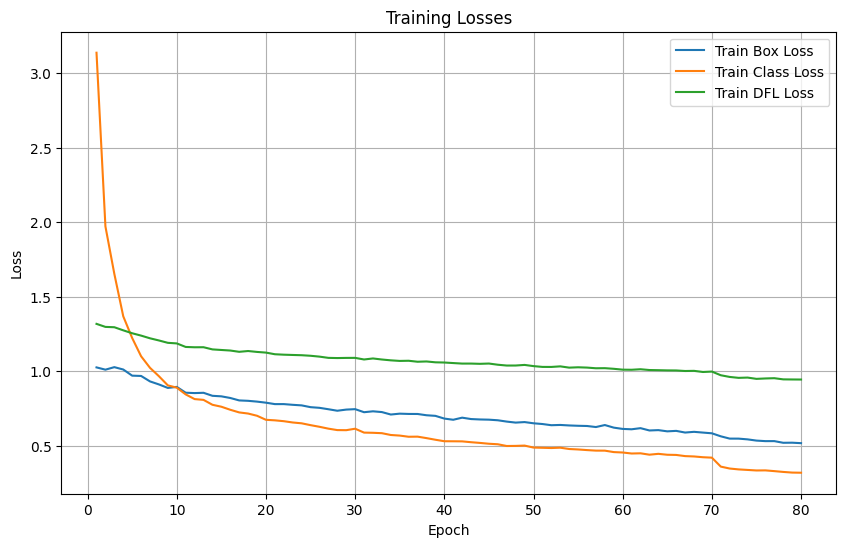

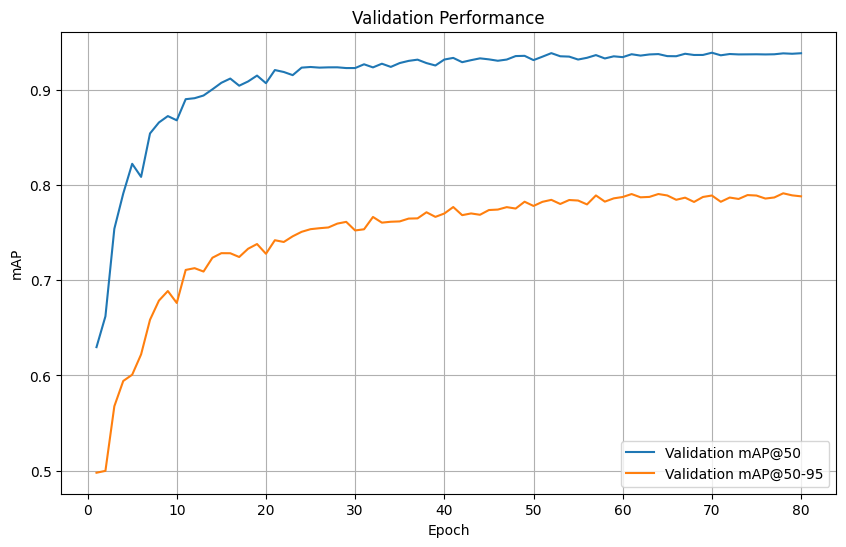

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

results_path = "/content/RoadSafety/YOLO11n_11classes/results.csv"

df = pd.read_csv(results_path)

print("Number of epochs:", len(df))
print("\nAvailable columns:")
print(df.columns.tolist())

# Plot training losses
plt.figure(figsize=(10, 6))

plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="Train Class Loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.legend()
plt.grid()
plt.show()

# Plot validation mAP
plt.figure(figsize=(10, 6))

plt.plot(
    df["epoch"],
    df["metrics/mAP50(B)"],
    label="Validation mAP@50"
)

plt.plot(
    df["epoch"],
    df["metrics/mAP50-95(B)"],
    label="Validation mAP@50-95"
)

plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.title("Validation Performance")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from ultralytics import YOLO

# Load the best trained model
best_model = YOLO(
    "/content/drive/MyDrive/RoadSafety_YOLO11/best.pt"
)

# Final evaluation on the TEST set
results = best_model.val(
    data="/content/Road_Safety_YOLO11_Balanced/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device='cpu',
    plots=True
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
YOLO11n summary (fused): 101 layers, 2,584,297 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 855.5±269.7 MB/s, size: 50.4 KB)
val: Scanning /content/Road_Safety_YOLO11_Balanced/test/labels... 669 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 669/669 1.8Kit/s 0.4s
val: New cache created: /content/Road_Safety_YOLO11_Balanced/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 42/42 3.5s/it 2:25
                   all        669        861      0.922      0.939      0.963      0.813
               pothole         55        193      0.793      0.851       0.87      0.684
                  Stop        123        126      0.898          1      0.993      0.857
            Pedestrian         77         83      0.878      0.892      0.917      0.659
       Speed_Limit_120         77         8

In [ ]:
from google.colab import drive
import os

if os.path.exists("/content/drive"):
    os.system("rm -rf /content/drive")

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import shutil

source_model = "/content/RoadSafety/YOLO11n_11classes/weights/best.pt"

drive_folder = "/content/drive/MyDrive/RoadSafety_YOLO11"

os.makedirs(drive_folder, exist_ok=True)

destination_model = os.path.join(
    drive_folder,
    "best.pt"
)

shutil.copy2(
    source_model,
    destination_model
)

print("Model saved successfully!")
print(destination_model)

Model saved successfully!
/content/drive/MyDrive/RoadSafety_YOLO11/best.pt


In [ ]:
import os
import shutil

source_model = "/content/RoadSafety/YOLO11n_11classes/weights/last.pt"

drive_folder = "/content/drive/MyDrive/RoadSafety_YOLO11"

os.makedirs(drive_folder, exist_ok=True)

destination_model = os.path.join(
    drive_folder,
    "last.pt"
)

shutil.copy2(
    source_model,
    destination_model
)

print("Model saved successfully!")
print(destination_model)

Model saved successfully!
/content/drive/MyDrive/RoadSafety_YOLO11/last.pt


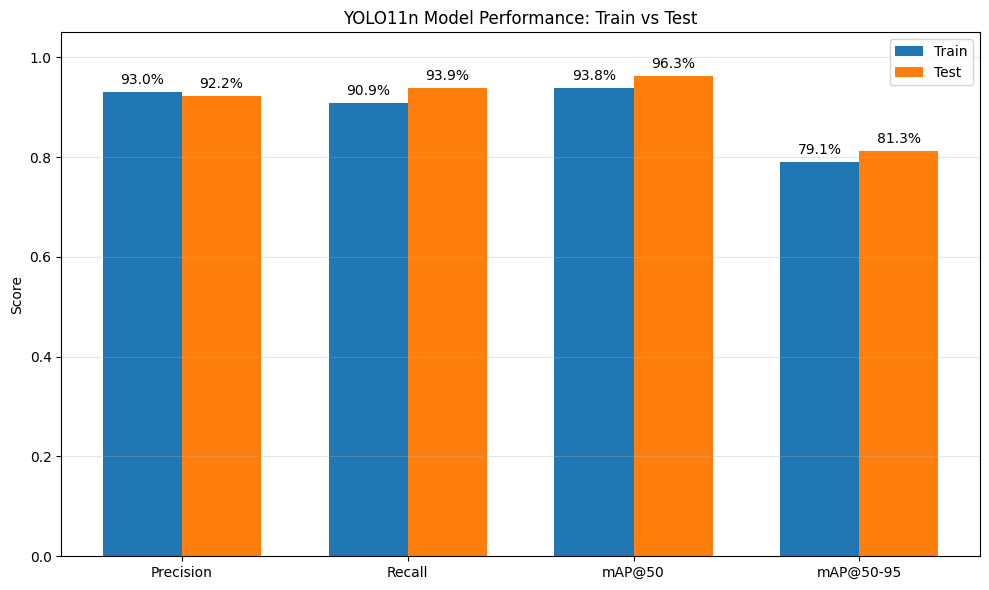

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Results
metrics = ['Precision', 'Recall', 'mAP@50', 'mAP@50-95']

train_values = [0.930, 0.909, 0.938, 0.791]
test_values  = [0.922, 0.939, 0.963, 0.813]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(x - width/2, train_values, width, label='Train')
bars2 = plt.bar(x + width/2, test_values, width, label='Test')

# Add values above bars
for bars in [bars1, bars2]:
    for bar in bars:
        value = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            value + 0.01,
            f'{value:.1%}',
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title('YOLO11n Model Performance: Train vs Test')
plt.ylabel('Score')
plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

,Class,Train Precision,Test Precision,Train Recall,Test Recall,Train mAP50,Test mAP50,Train mAP50-95,Test mAP50-95
0,pothole,0.878,0.793,0.802,0.851,0.885,0.870,0.676,0.684
1,Stop,0.980,0.898,1.000,1.000,0.995,0.993,0.875,0.857
2,Pedestrian,0.921,0.878,0.840,0.892,0.860,0.917,0.639,0.659
3,Speed_Limit_120,0.957,0.942,0.991,0.965,0.995,0.987,0.843,0.839
4,Speed_Limit_40,0.899,0.938,0.938,0.899,0.973,0.981,0.883,0.888
5,No_U-Turn,0.996,0.987,0.989,0.994,0.985,0.995,0.859,0.882
6,Speed_Limit_90,0.934,0.927,0.977,0.964,0.981,0.984,0.907,0.899
7,No_Stopping,0.931,0.941,0.814,0.911,0.879,0.936,0.701,0.770
8,No_Parking,1.000,0.948,0.997,0.995,0.995,0.994,0.840,0.836
9,Bump,0.847,0.907,0.793,0.915,0.870,0.957,0.707,0.759


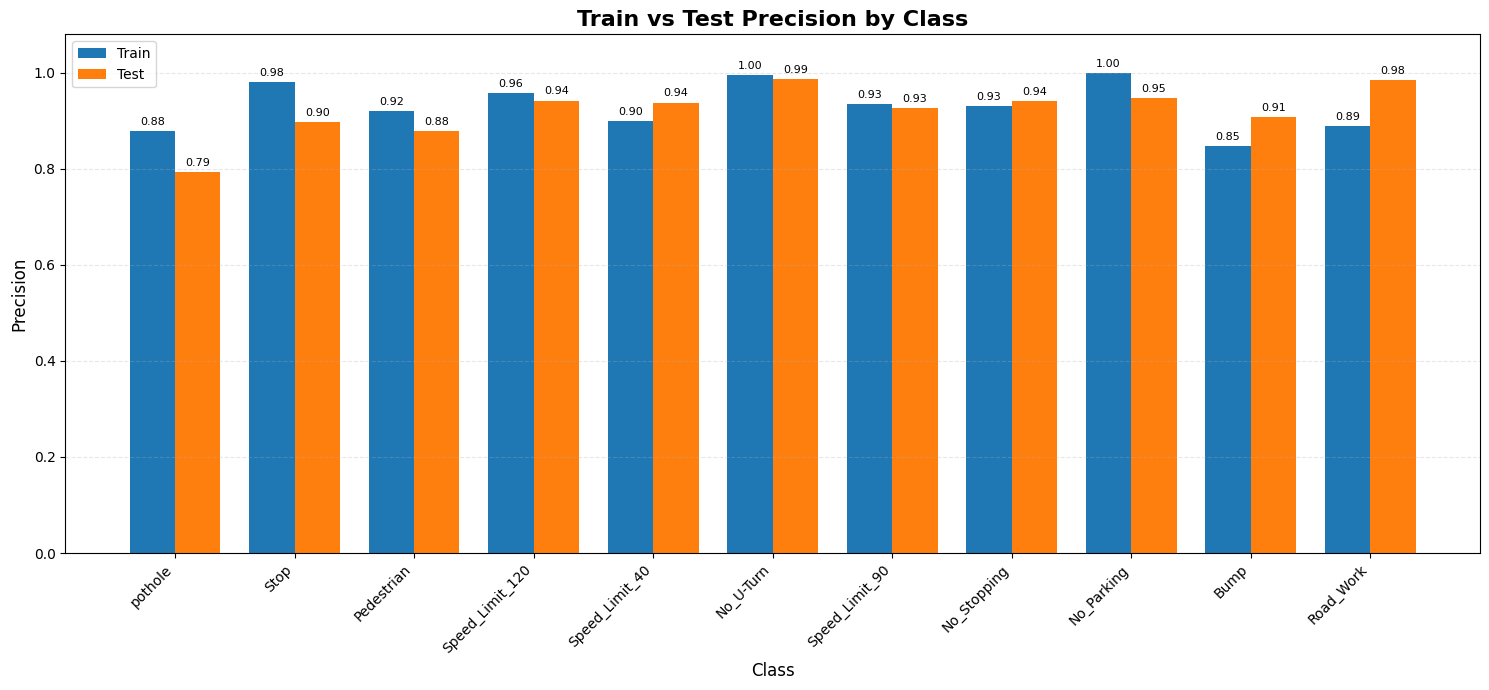

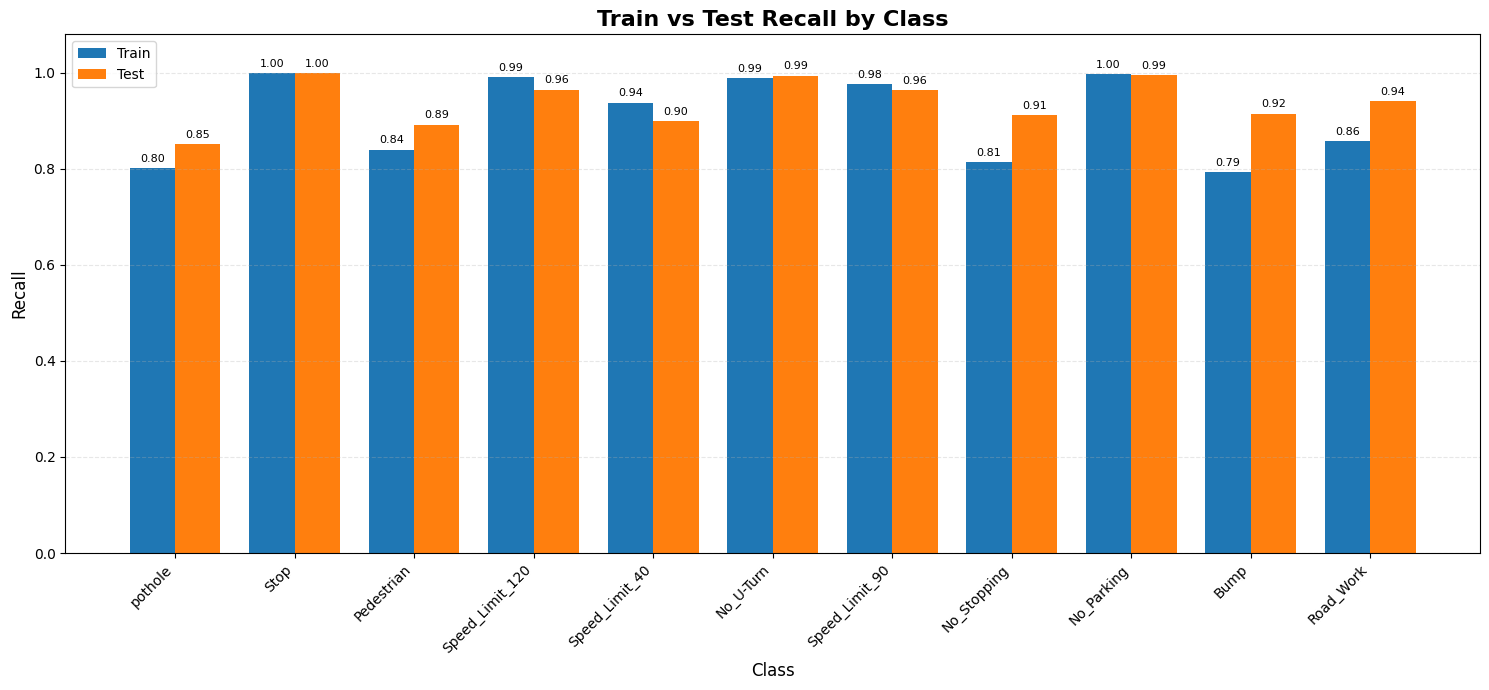

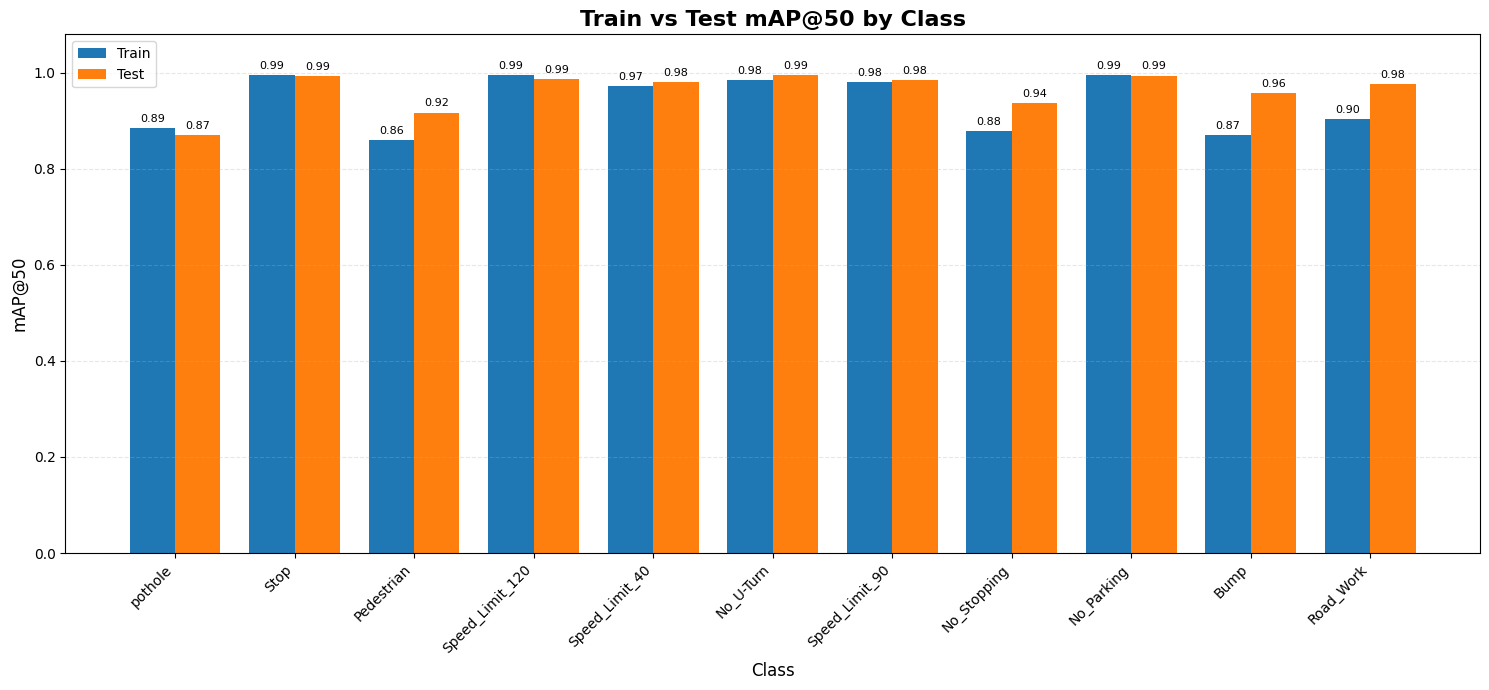

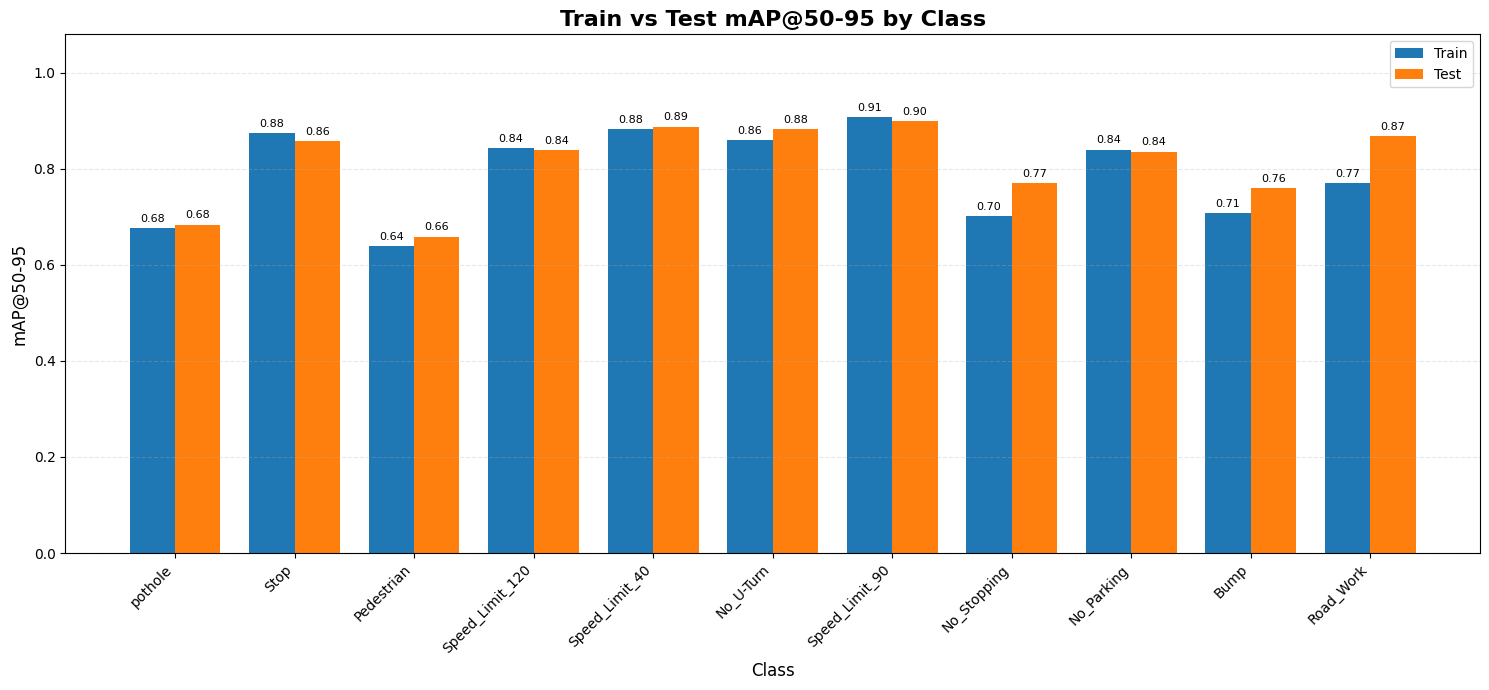

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Data
# =========================

classes = [
    "pothole",
    "Stop",
    "Pedestrian",
    "Speed_Limit_120",
    "Speed_Limit_40",
    "No_U-Turn",
    "Speed_Limit_90",
    "No_Stopping",
    "No_Parking",
    "Bump",
    "Road_Work"
]

# Train results
train_precision = [0.878, 0.980, 0.921, 0.957, 0.899, 0.996, 0.934, 0.931, 1.000, 0.847, 0.889]
train_recall    = [0.802, 1.000, 0.840, 0.991, 0.938, 0.989, 0.977, 0.814, 0.997, 0.793, 0.857]
train_map50     = [0.885, 0.995, 0.860, 0.995, 0.973, 0.985, 0.981, 0.879, 0.995, 0.870, 0.904]
train_map5095   = [0.676, 0.875, 0.639, 0.843, 0.883, 0.859, 0.907, 0.701, 0.840, 0.707, 0.770]

# Test results
test_precision = [0.793, 0.898, 0.878, 0.942, 0.938, 0.987, 0.927, 0.941, 0.948, 0.907, 0.985]
test_recall    = [0.851, 1.000, 0.892, 0.965, 0.899, 0.994, 0.964, 0.911, 0.995, 0.915, 0.941]
test_map50     = [0.870, 0.993, 0.917, 0.987, 0.981, 0.995, 0.984, 0.936, 0.994, 0.957, 0.977]
test_map5095   = [0.684, 0.857, 0.659, 0.839, 0.888, 0.882, 0.899, 0.770, 0.836, 0.759, 0.868]


# =========================
# Create DataFrame
# =========================

df = pd.DataFrame({
    "Class": classes,

    "Train Precision": train_precision,
    "Test Precision": test_precision,

    "Train Recall": train_recall,
    "Test Recall": test_recall,

    "Train mAP50": train_map50,
    "Test mAP50": test_map50,

    "Train mAP50-95": train_map5095,
    "Test mAP50-95": test_map5095
})

# Display results
display(df.round(3))


# =========================
# Plot function
# =========================

def plot_train_test(train_values, test_values, metric, title):

    x = np.arange(len(classes))
    width = 0.38

    fig, ax = plt.subplots(figsize=(15, 7))

    bars1 = ax.bar(
        x - width/2,
        train_values,
        width,
        label="Train"
    )

    bars2 = ax.bar(
        x + width/2,
        test_values,
        width,
        label="Test"
    )

    ax.set_title(title, fontsize=16, fontweight="bold")
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xlabel("Class", fontsize=12)

    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=45, ha="right")

    ax.set_ylim(0, 1.08)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    ax.legend()

    # Add values on bars
    ax.bar_label(
        bars1,
        fmt="%.2f",
        padding=3,
        fontsize=8
    )

    ax.bar_label(
        bars2,
        fmt="%.2f",
        padding=3,
        fontsize=8
    )

    plt.tight_layout()
    plt.show()


# =========================
# Generate Charts
# =========================

plot_train_test(
    train_precision,
    test_precision,
    "Precision",
    "Train vs Test Precision by Class"
)

plot_train_test(
    train_recall,
    test_recall,
    "Recall",
    "Train vs Test Recall by Class"
)

plot_train_test(
    train_map50,
    test_map50,
    "mAP@50",
    "Train vs Test mAP@50 by Class"
)

plot_train_test(
    train_map5095,
    test_map5095,
    "mAP@50-95",
    "Train vs Test mAP@50-95 by Class"
)

In [ ]:
import gradio as gr
from ultralytics import YOLO
from collections import Counter
import cv2
import os

model = YOLO(
    "/content/drive/MyDrive/RoadSafety_YOLO11/best.pt"
)

def count_detections(result):

    counts = Counter()

    if result.boxes is not None:

        for cls_id in result.boxes.cls.tolist():

            class_id = int(cls_id)
            class_name = model.names[class_id]

            counts[class_name] += 1

    return counts


def create_report(counts):

    potholes = counts.get("pothole", 0)

    traffic_signs = sum(
        count
        for name, count in counts.items()
        if name != "pothole"
    )

    total_objects = potholes + traffic_signs

    report = "## 🚦 Road Analysis\n\n"

    report += f"### 🕳️ Potholes: **{potholes}**\n\n"

    report += f"### 🚦 Traffic Signs: **{traffic_signs}**\n\n"

    report += f"### 📦 Total Objects: **{total_objects}**\n\n"

    if traffic_signs > 0:

        report += "### Traffic Sign Details\n\n"

        for name, count in counts.items():

            if name != "pothole":

                report += f"- **{name}:** {count}\n"

    return report


def detect_image(image):

    results = model.predict(
        source=image,
        imgsz=640,
        conf=0.25,
        verbose=False
    )

    result = results[0]

    annotated_image = result.plot()

    counts = count_detections(result)

    report = create_report(counts)

    return annotated_image, report


def detect_video(video_path):

    if video_path is None:
        return None, "Please upload a video."

    cap = cv2.VideoCapture(video_path)

    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps <= 0:
        fps = 30

    width = int(
        cap.get(cv2.CAP_PROP_FRAME_WIDTH)
    )

    height = int(
        cap.get(cv2.CAP_PROP_FRAME_HEIGHT)
    )

    output_path = "/content/detected_video.mp4"

    fourcc = cv2.VideoWriter_fourcc(
        *"mp4v"
    )

    out = cv2.VideoWriter(
        output_path,
        fourcc,
        fps,
        (width, height)
    )

    frame_count = 0

    max_potholes = 0
    max_traffic_signs = 0

    while True:

        ret, frame = cap.read()

        if not ret:
            break

        results = model.predict(
            source=frame,
            imgsz=640,
            conf=0.25,
            verbose=False
        )

        result = results[0]

        annotated_frame = result.plot()

        counts = count_detections(result)

        potholes = counts.get(
            "pothole",
            0
        )

        traffic_signs = sum(
            count
            for name, count in counts.items()
            if name != "pothole"
        )

        max_potholes = max(
            max_potholes,
            potholes
        )

        max_traffic_signs = max(
            max_traffic_signs,
            traffic_signs
        )

        out.write(annotated_frame)

        frame_count += 1

    cap.release()
    out.release()

    report = "## 🎥 Video Analysis\n\n"

    report += (
        f"### 🕳️ Maximum Potholes in One Frame: "
        f"**{max_potholes}**\n\n"
    )

    report += (
        f"### 🚦 Maximum Traffic Signs in One Frame: "
        f"**{max_traffic_signs}**\n\n"
    )

    report += (
        f"### 🎞️ Frames Processed: "
        f"**{frame_count}**"
    )

    return output_path, report


with gr.Blocks() as demo:

    gr.Markdown(
        "# 🚦 Road Safety Detection"
    )

    gr.Markdown(
        "YOLO11 detects potholes and traffic signs "
        "from images and videos."
    )

    with gr.Tab("📷 Image Detection"):

        image_input = gr.Image(
            type="numpy",
            label="Upload Road Image"
        )

        image_button = gr.Button(
            "🔍 Detect"
        )

        image_output = gr.Image(
            type="numpy",
            label="Detection Result"
        )

        image_report = gr.Markdown()

        image_button.click(
            detect_image,
            inputs=image_input,
            outputs=[
                image_output,
                image_report
            ]
        )

    with gr.Tab("🎥 Video Detection"):

        video_input = gr.Video(
            label="Upload Road Video"
        )

        video_button = gr.Button(
            "🔍 Detect Video"
        )

        video_output = gr.Video(
            label="Detection Result"
        )

        video_report = gr.Markdown()

        video_button.click(
            detect_video,
            inputs=video_input,
            outputs=[
                video_output,
                video_report
            ]
        )

demo.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ec6f5187d4d5944905.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
